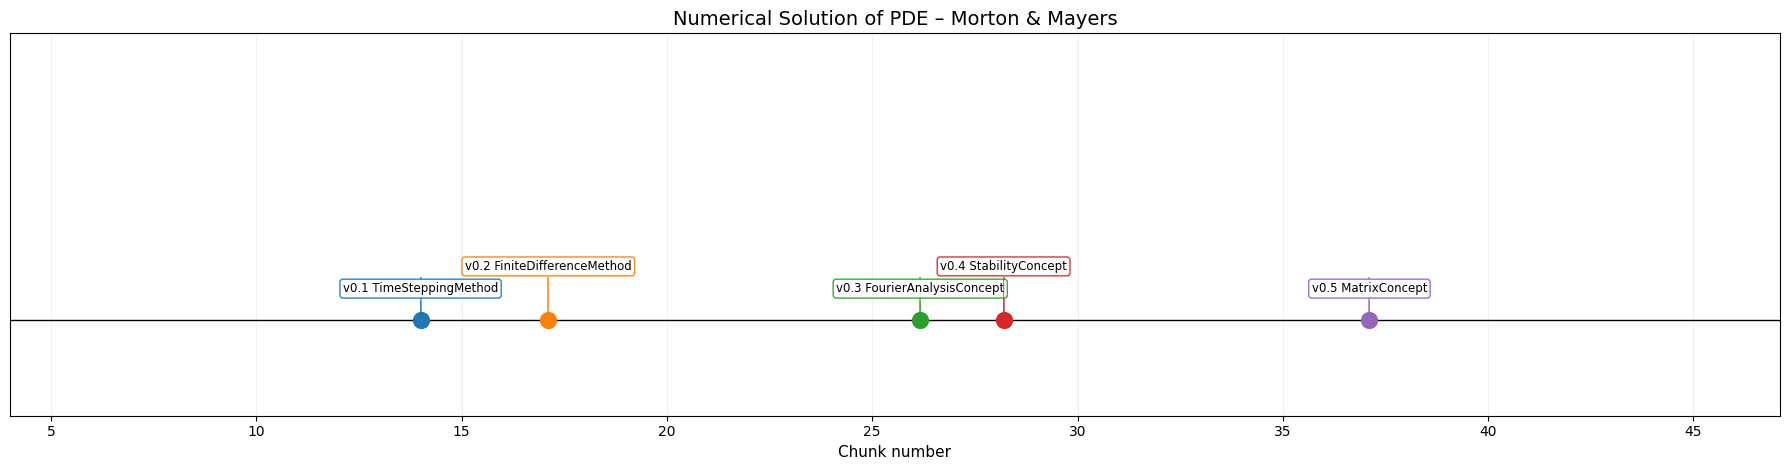

Saved figure to: D:\Thesis\Mark_1\notebooks\ontology_timeline.png


In [4]:
import json
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT_DIR = Path.cwd().parent
ASCHER_GREIF_JSONL = ROOT_DIR / "logs" / "ascher_greif_run_1_auto_run_20260502_013713.jsonl"
MORTON_PDE_JSONL = ROOT_DIR / "logs" / "morton_pde_run_1_auto_run_20260503_214810.jsonl"

# ------------------------------------------------------------
# INPUT FILES
# ------------------------------------------------------------
RUNS = [
    # {
    #     "name": "A First Course in Numerical Methods – Ascher & Greif",
    #     "jsonl": ASCHER_GREIF_JSONL,
    # },
    {
        "name": "Numerical Solution of PDE – Morton & Mayers",
        "jsonl": MORTON_PDE_JSONL,
    },
]

OUT_PNG = Path("ontology_timeline.png")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def extract_chunk_number(chunk_id: str):
    """
    Extract numeric suffix from chunk ids like:
      "..._chunk_77"
      "..._chunk_94.9"
      "..._chunk_14.1"
    """
    m = re.search(r"_chunk_(\d+(?:\.\d+)?)$", chunk_id or "")
    return float(m.group(1)) if m else None


def load_extension_events(jsonl_path: Path):
    """
    Read only OntologyProposerAgent extension events.
    Returns a list of dicts with:
      chunk_num, chunk_id, version, new_classes, ts
    """
    events = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            if obj.get("event") != "extensions_applied":
                continue

            data = obj.get("data", {})
            chunk_id = obj.get("chunk_id", "")
            events.append({
                "ts": obj.get("ts"),
                "chunk_id": chunk_id,
                "chunk_num": extract_chunk_number(chunk_id),
                "version": data.get("version", ""),
                "new_classes": data.get("new_classes", []),
                "path": data.get("path", ""),
            })

    # Sort by chunk number, then timestamp
    events.sort(key=lambda x: (
        x["chunk_num"] if x["chunk_num"] is not None else 1e18,
        x["ts"] or ""
    ))
    return events


def format_label(version: str, new_classes: list[str], width: int = 28) -> str:
    """
    Wrap the label so it stays readable above the marker.
    """
    class_text = ", ".join(new_classes) if new_classes else "No new classes"
    raw = f"v{version}\n{class_text}"
    return "\n".join(textwrap.wrap(raw, width=width, break_long_words=False))


# ------------------------------------------------------------
# LOAD EVENTS
# ------------------------------------------------------------
runs = []
for run in RUNS:
    events = load_extension_events(run["jsonl"])
    runs.append({
        "name": run["name"],
        "jsonl": run["jsonl"],
        "events": events,
    })

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
n = len(runs)
fig, axes = plt.subplots(n, 1, figsize=(18, 4.8 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, run in zip(axes, runs):
    events = run["events"]

    ax.axhline(0, color="black", lw=1)
    ax.set_yticks([])
    ax.set_ylim(-0.4, 1.2)

    if not events:
        ax.text(
            0.5, 0.5, "No ontology extensions found",
            transform=ax.transAxes, ha="center", va="center", fontsize=12
        )
        ax.set_title(run["name"])
        continue

    xs = [e["chunk_num"] for e in events if e["chunk_num"] is not None]
    if not xs:
        ax.text(
            0.5, 0.5, "Could not parse chunk numbers",
            transform=ax.transAxes, ha="center", va="center", fontsize=12
        )
        ax.set_title(run["name"])
        continue

    xmin = max(0, min(xs) - 10)
    xmax = max(xs) + 10

    # small alternating offsets to reduce label collisions
    offsets = [18, 34, 18, 34, 18, 34, 18, 34, 18, 34]

    for i, e in enumerate(events):
        x = e["chunk_num"]
        if x is None:
            continue

        color = plt.cm.tab10(i % 10)
        ax.scatter([x], [0], s=130, color=color, zorder=3)
        ax.vlines(x, 0, 0.18, colors=color, lw=1.2, alpha=0.75)

        label = format_label(e["version"], e["new_classes"], width=30)
        y_offset = offsets[i % len(offsets)]

        ax.annotate(
            label,
            xy=(x, 0),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, alpha=0.92),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.8, alpha=0.7),
        )

    ax.set_xlim(xmin, xmax)
    ax.set_title(run["name"], fontsize=14)
    ax.set_xlabel("Chunk number", fontsize=11)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
    ax.grid(axis="x", alpha=0.18)

# fig.suptitle(
#     "Ontology growth over document progression",
#     fontsize=16,
#     y=0.995
# )

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PNG.resolve()}")